# Triton Basics

In [1]:
!nvidia-smi

Sat Apr 19 07:33:52 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.171.04             Driver Version: 535.171.04   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        On  | 00000000:18:00.0 Off |                  Off |
|  0%   33C    P8               9W / 450W |  19948MiB / 24564MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import torch
import triton
import triton.language as tl

In [3]:
DEVICE = 'cuda'

## Write a reference kernel as baseline

In [4]:
def ref_vector_add(x, y):
    output = torch.add(x, y)
    return output

## Write Triton kernel

In [5]:
@triton.jit
def vector_add_kernel(x_ptr, y_ptr, output_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    # 0 1 2 3 
    # x[0] - x[3]
    # x[0 + pid]
    # Indexing
    block_start = pid * BLOCK_SIZE
    # x[0:3] x[4:8]
    # x[0+4:3+4]
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    # 0 1 2 
    # 0 1 2 0
    
    mask = offsets < n_elements
    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)
    result = x + y   # shape: (BLOCKSize)
    # output[0:3]
    tl.store(output_ptr + offsets, result, mask=mask)

## Helper function to allocate tensors

In [6]:
def triton_vector_add(x, y):
    output = torch.empty_like(x)
    size = x.numel()
    BLOCK_SIZE = 1024

    # grid = lambda META: (triton.cdiv(size, META['BLOCK_SIZE']),)
    grid = (triton.cdiv(size, BLOCK_SIZE),)
    vector_add_kernel[grid](x, y, output, size, BLOCK_SIZE=BLOCK_SIZE)

    return output


## Test the correctness

In [7]:
def test():
    size = 1024
    x = torch.randn(size, device=DEVICE)
    y = torch.randn(size, device=DEVICE)
    output_ref = ref_vector_add(x, y)

    output_triton = triton_vector_add(x, y)    

    # torch.testing.assertclose
    if torch.allclose(output_ref, output_triton, atol=1e-6):
        print("✅ Triton kernel is correct!")
    else:
        print("❌ Triton kernel is incorrect.")

test()

✅ Triton kernel is correct!


## Benchmark with `triton.testing.do_bench`

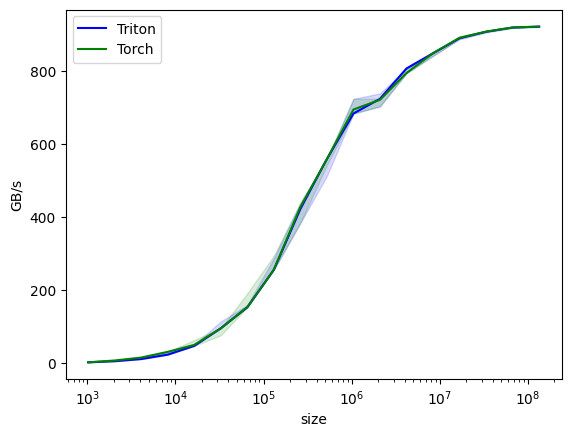

vector-add-performance:
           size      Triton       Torch
0        1024.0    3.011765    3.000000
1        2048.0    6.144000    8.000000
2        4096.0   12.000000   15.999999
3        8192.0   24.000000   31.670104
4       16384.0   48.000000   50.567902
5       32768.0   96.000000   96.000000
6       65536.0  153.600004  153.600004
7      131072.0  255.999991  255.999991
8      262144.0  421.905581  427.408686
9      524288.0  558.545450  558.545450
10    1048576.0  682.666643  693.502633
11    2097152.0  722.823517  720.175792
12    4194304.0  805.770507  793.173993
13    8388608.0  847.334119  847.448255
14   16777216.0  888.247334  889.628980
15   33554432.0  906.027677  906.419248
16   67108864.0  917.656936  917.640201
17  134217728.0  919.921195  920.341734


<Figure size 640x480 with 0 Axes>

In [8]:
import os

@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2 ** i for i in range(10, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: ref_vector_add(x, y), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: triton_vector_add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True, save_path=os.path.abspath("../benchmark"))